# Two-Stage Sentiment Classifier — Stock Social Media Posts

Predicts sentiment class (`-1` = Bearish, `0` = Neutral, `1` = Bullish) from post text using a **two-stage pipeline**:

| Stage | Task                                    | Model              | Input                                   |
| ----- | --------------------------------------- | ------------------ | --------------------------------------- |
| **1** | "Has sentiment?" — Sentiment vs Neutral | LinearSVC + TF-IDF | All posts                               |
| **2** | "Which direction?" — Bullish vs Bearish | XGBoost + TF-IDF   | Only posts Stage 1 flagged as sentiment |

Each stage has its own TF-IDF vectorizer (separate vocabularies). The final 3-class prediction combines both stages.

**Metrics reported per stock**: Accuracy, Confusion Matrix, Precision, Recall, F1 Score, MCC


In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    matthews_corrcoef,
)
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── Configuration ─────────────────────────────────────────────
DATA_DIR = os.path.join("..", "pre-processing")   # path to _final.csv files
STOCKS = ["AAPL", "AMZN", "FB", "NVDA", "TSLA"]
RANDOM_STATE = 42
TEST_SIZE = 0.20

# TF-IDF settings (separate per stage)
MAX_TFIDF_FEATURES_S1 = 10_000   # Stage 1: Sentiment vs Neutral
MAX_TFIDF_FEATURES_S2 = 5_000    # Stage 2: Bullish vs Bearish

# Label mappings
LABEL_MAP = {-1: "Bearish", 0: "Neutral", 1: "Bullish"}
LABEL_ORDER = [-1, 0, 1]
LABEL_NAMES = ["Bearish", "Neutral", "Bullish"]

# XGBoost needs 0-indexed classes for Stage 2
S2_LABEL_REMAP = {-1: 0, 1: 1}   # Bearish→0, Bullish→1
S2_LABEL_UNMAP = {0: -1, 1: 1}   # 0→Bearish, 1→Bullish

## 1 — Load Data, Undersample Neutral, Chronological Sort

Each stock dataset is loaded, sorted by date, and Neutral posts are undersampled to match the Bullish count (evenly spaced chronologically to preserve time coverage). This gives Stage 1 a manageable ~60/40 sentiment-vs-neutral split.


In [3]:
# ── Load data, undersample Neutral to match Bullish, sort chronologically ──
ts_data = {}

for stock in STOCKS:
    path = os.path.join(DATA_DIR, f"{stock}_final.csv")
    print(f"Loading {stock} from {path} ...")
    df = pd.read_csv(path, low_memory=False)

    # Parse and sort by date
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
    df = df.sort_values("created_at").reset_index(drop=True)

    # Drop rows with missing text
    df = df.dropna(subset=["body_no_stopwords"]).reset_index(drop=True)

    # Split by class
    bearish = df[df["entities"] == -1]
    neutral = df[df["entities"] == 0]
    bullish = df[df["entities"] == 1]

    print(f"  Original:  Bearish={len(bearish):>8,}  Neutral={len(neutral):>8,}  Bullish={len(bullish):>8,}  Total={len(df):>10,}")

    # Undersample Neutral: cap at Bullish count, evenly spaced to preserve time coverage
    target_neutral = len(bullish)
    if len(neutral) > target_neutral:
        indices = np.linspace(0, len(neutral) - 1, target_neutral, dtype=int)
        neutral_sampled = neutral.iloc[indices]
    else:
        neutral_sampled = neutral

    # Recombine and re-sort chronologically
    df = pd.concat([bearish, neutral_sampled, bullish], axis=0)
    df = df.sort_values("created_at").reset_index(drop=True)

    print(f"  Sampled:   Bearish={len(bearish):>8,}  Neutral={len(neutral_sampled):>8,}  Bullish={len(bullish):>8,}  Total={len(df):>10,}")
    counts = df["entities"].value_counts().sort_index()
    for label_val, count in counts.items():
        pct = count / len(df) * 100
        print(f"    {LABEL_MAP.get(label_val, label_val)}: {count:,} ({pct:.1f}%)")
    print(f"  Date range: {df['created_at'].min()} → {df['created_at'].max()}")
    print()

    ts_data[stock] = df

print("All datasets loaded (Neutral undersampled, chronological order).")

Loading AAPL from ..\pre-processing\AAPL_final.csv ...
  Original:  Bearish= 107,549  Neutral= 461,513  Bullish= 345,900  Total=   914,962
  Sampled:   Bearish= 107,549  Neutral= 345,900  Bullish= 345,900  Total=   799,349
    Bearish: 107,549 (13.5%)
    Neutral: 345,900 (43.3%)
    Bullish: 345,900 (43.3%)
  Date range: 2019-12-31 21:07:39+00:00 → 2022-02-27 15:17:51+00:00

Loading AMZN from ..\pre-processing\AMZN_final.csv ...
  Original:  Bearish=  48,336  Neutral= 303,319  Bullish= 188,148  Total=   539,803
  Sampled:   Bearish=  48,336  Neutral= 188,148  Bullish= 188,148  Total=   424,632
    Bearish: 48,336 (11.4%)
    Neutral: 188,148 (44.3%)
    Bullish: 188,148 (44.3%)
  Date range: 2019-07-23 21:14:41+00:00 → 2022-03-05 14:16:48+00:00

Loading FB from ..\pre-processing\FB_final.csv ...
  Original:  Bearish=  47,400  Neutral= 198,047  Bullish= 114,461  Total=   359,908
  Sampled:   Bearish=  47,400  Neutral= 114,461  Bullish= 114,461  Total=   276,322
    Bearish: 47,400 (17.

## 2 — Chronological 80/20 Split

Data is split by date (first 80% train, last 20% test). We keep the raw DataFrames so each stage can fit its own TF-IDF independently — no vocabulary leakage.


In [4]:
# ── Chronological 80/20 split — keep raw DataFrames for per-stage TF-IDF ──
ts_frames = {}  # stock → (train_df, test_df)

for stock in STOCKS:
    df = ts_data[stock]
    n = len(df)
    split_idx = int(n * (1 - TEST_SIZE))  # 80/20 chronological

    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()

    print(f"{stock}:")
    print(f"  Train: {len(train_df):,} rows  ({train_df['created_at'].min().date()} → {train_df['created_at'].max().date()})")
    print(f"  Test:  {len(test_df):,} rows  ({test_df['created_at'].min().date()} → {test_df['created_at'].max().date()})")

    # Verify no date leakage
    assert train_df["created_at"].max() <= test_df["created_at"].min(), "Date leakage detected!"

    # Show class distribution in train vs test
    for split_label, split_df in [("Train", train_df), ("Test", test_df)]:
        counts = split_df["entities"].value_counts().sort_index()
        dist = "  |  ".join(f"{LABEL_MAP[k]}: {v:,}" for k, v in counts.items())
        print(f"  {split_label} classes: {dist}")
    print()

    ts_frames[stock] = (train_df, test_df)

print("Chronological splits ready.")

AAPL:
  Train: 639,479 rows  (2019-12-31 → 2021-09-02)
  Test:  159,870 rows  (2021-09-02 → 2022-02-27)
  Train classes: Bearish: 82,722  |  Neutral: 277,496  |  Bullish: 279,261
  Test classes: Bearish: 24,827  |  Neutral: 68,404  |  Bullish: 66,639

AMZN:
  Train: 339,705 rows  (2019-07-23 → 2021-09-28)
  Test:  84,927 rows  (2021-09-28 → 2022-03-05)
  Train classes: Bearish: 35,748  |  Neutral: 152,812  |  Bullish: 151,145
  Test classes: Bearish: 12,588  |  Neutral: 35,336  |  Bullish: 37,003

FB:
  Train: 221,057 rows  (2019-07-23 → 2022-02-02)
  Test:  55,265 rows  (2022-02-02 → 2022-03-05)
  Train classes: Bearish: 31,144  |  Neutral: 94,756  |  Bullish: 95,157
  Test classes: Bearish: 16,256  |  Neutral: 19,705  |  Bullish: 19,304

NVDA:
  Train: 346,580 rows  (2013-04-11 → 2021-08-25)
  Test:  86,646 rows  (2021-08-25 → 2022-02-28)
  Train classes: Bearish: 40,224  |  Neutral: 160,959  |  Bullish: 145,397
  Test classes: Bearish: 9,460  |  Neutral: 30,812  |  Bullish: 46,374



## 3 — Stage 1: Sentiment vs Neutral (LinearSVC)

Binary classifier: **"Does this post have sentiment?"**

- Labels remapped: Bearish(-1) → 1, Bullish(1) → 1, Neutral(0) → 0
- Own TF-IDF vectorizer (10K features, unigrams + bigrams) fit on **training data only**
- `LinearSVC(class_weight='balanced')` handles the ~60/40 imbalance


In [5]:
# ── Stage 1: Sentiment vs Neutral (LinearSVC) ─────────────────────────
S1_NAMES = ["Neutral", "Sentiment"]

stage1 = {}  # stock → dict of model, vectorizer, metrics, predictions

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]

    # Remap labels: Bearish(-1)→1, Bullish(1)→1, Neutral(0)→0
    y_train_s1 = (train_df["entities"] != 0).astype(int).values   # 0=Neutral, 1=Sentiment
    y_test_s1  = (test_df["entities"] != 0).astype(int).values

    # Fit TF-IDF on training text only
    vec_s1 = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES_S1,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    X_train_s1 = vec_s1.fit_transform(train_df["body_no_stopwords"])
    X_test_s1  = vec_s1.transform(test_df["body_no_stopwords"])

    # Train LinearSVC
    clf_s1 = LinearSVC(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        dual="auto",
    )
    clf_s1.fit(X_train_s1, y_train_s1)
    y_pred_s1 = clf_s1.predict(X_test_s1)

    # Metrics
    acc = accuracy_score(y_test_s1, y_pred_s1)
    mcc = matthews_corrcoef(y_test_s1, y_pred_s1)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_s1, y_pred_s1, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_test_s1, y_pred_s1, labels=[0, 1])

    stage1[stock] = {
        "clf": clf_s1, "vec": vec_s1,
        "accuracy": acc, "mcc": mcc,
        "f1_weighted": f1_w, "precision_weighted": prec_w, "recall_weighted": rec_w,
        "cm": cm, "y_test": y_test_s1, "y_pred": y_pred_s1,
        "X_test": X_test_s1,
    }

    # Print report
    print("=" * 60)
    print(f"  {stock} — Stage 1: Sentiment vs Neutral (LinearSVC)")
    print("=" * 60)
    print(f"  Accuracy : {acc:.4f}   MCC : {mcc:.4f}   F1 (wtd) : {f1_w:.4f}")
    print()
    print(classification_report(
        y_test_s1, y_pred_s1, labels=[0, 1],
        target_names=S1_NAMES, zero_division=0
    ))

    # Key stat: sentiment recall (how many true-sentiment posts does Stage 1 catch?)
    sent_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    print(f"  ⚡ Sentiment recall: {sent_recall:.4f} — {cm[1,1]:,} of {cm[1,0]+cm[1,1]:,} sentiment posts forwarded to Stage 2")
    print()

print("Stage 1 complete for all stocks.")

  AAPL — Stage 1: Sentiment vs Neutral (LinearSVC)
  Accuracy : 0.6356   MCC : 0.2525   F1 (wtd) : 0.6347

              precision    recall  f1-score   support

     Neutral       0.58      0.56      0.57     68404
   Sentiment       0.68      0.69      0.69     91466

    accuracy                           0.64    159870
   macro avg       0.63      0.63      0.63    159870
weighted avg       0.63      0.64      0.63    159870

  ⚡ Sentiment recall: 0.6947 — 63,544 of 91,466 sentiment posts forwarded to Stage 2

  AMZN — Stage 1: Sentiment vs Neutral (LinearSVC)
  Accuracy : 0.6362   MCC : 0.2483   F1 (wtd) : 0.6354

              precision    recall  f1-score   support

     Neutral       0.56      0.55      0.56     35336
   Sentiment       0.68      0.70      0.69     49591

    accuracy                           0.64     84927
   macro avg       0.62      0.62      0.62     84927
weighted avg       0.63      0.64      0.64     84927

  ⚡ Sentiment recall: 0.6989 — 34,657 of 49,59

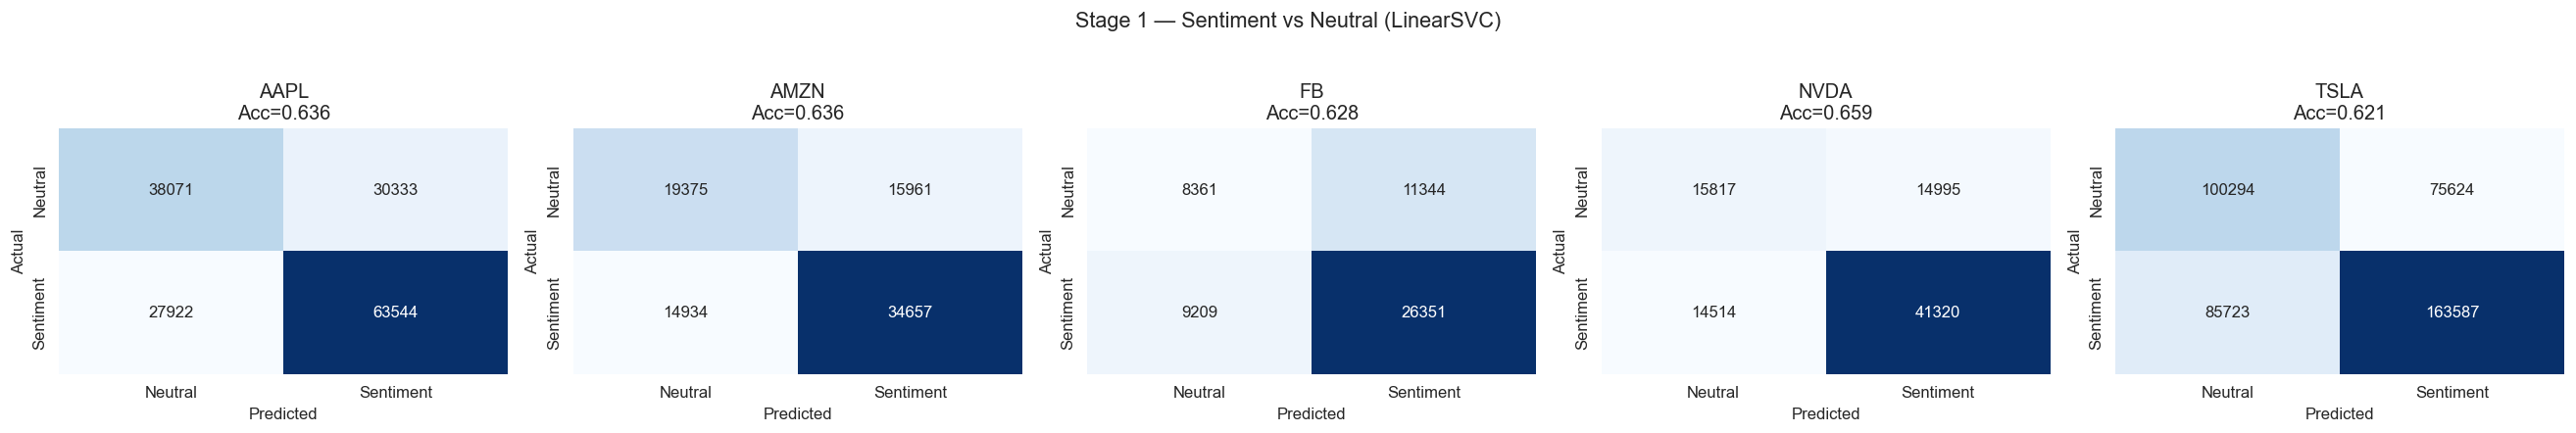

Saved → stage1_confusion_matrices.png


In [6]:
# ── Stage 1 Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
fig.suptitle("Stage 1 — Sentiment vs Neutral (LinearSVC)", fontsize=13, y=1.04)

for ax, stock in zip(axes, STOCKS):
    cm = stage1[stock]["cm"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=S1_NAMES, yticklabels=S1_NAMES,
        ax=ax, cbar=False,
    )
    acc = stage1[stock]["accuracy"]
    ax.set_title(f"{stock}\nAcc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("stage1_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → stage1_confusion_matrices.png")

## 4 — Stage 2: Bullish vs Bearish (XGBoost)

Binary classifier: **"Which direction is the sentiment?"**

- **Training**: fit only on Bearish + Bullish rows from the training set (Neutral excluded)
- Own TF-IDF vectorizer (5K features) — learns vocabulary tuned for Bullish-vs-Bearish without neutral noise
- `XGBClassifier` with `sample_weight='balanced'` handles the ~3:1 Bullish:Bearish imbalance
- **Inference**: applied only to test posts that Stage 1 predicted as "has sentiment"


In [7]:
# ── Stage 2: Bullish vs Bearish (XGBoost) ─────────────────────────────
S2_NAMES = ["Bearish", "Bullish"]
S2_ORDER = [-1, 1]

stage2 = {}  # stock → dict of model, vectorizer, metrics, predictions

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]

    # ── Training: only Bearish + Bullish rows ────────────────────────
    train_sent = train_df[train_df["entities"].isin([-1, 1])].copy()
    print(f"{stock} — Stage 2 training on {len(train_sent):,} sentiment rows "
          f"(Bearish={sum(train_sent['entities']==-1):,}, Bullish={sum(train_sent['entities']==1):,})")

    # Fit Stage 2 TF-IDF on sentiment training text only
    vec_s2 = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES_S2,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    X_train_s2 = vec_s2.fit_transform(train_sent["body_no_stopwords"])
    y_train_s2_raw = train_sent["entities"].values  # -1 or 1

    # Remap for XGBoost: Bearish(-1)→0, Bullish(1)→1
    y_train_s2 = np.array([S2_LABEL_REMAP[y] for y in y_train_s2_raw])

    # Balanced sample weights
    sw = compute_sample_weight("balanced", y_train_s2)

    # Train XGBoost
    clf_s2 = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    clf_s2.fit(X_train_s2, y_train_s2, sample_weight=sw)

    # ── Evaluate Stage 2 on TRUE sentiment test posts ────────────────
    # (This shows Stage 2 accuracy in isolation, independent of Stage 1 errors)
    test_sent = test_df[test_df["entities"].isin([-1, 1])].copy()
    X_test_s2_true = vec_s2.transform(test_sent["body_no_stopwords"])
    y_test_s2_raw = test_sent["entities"].values
    y_pred_s2_xgb = clf_s2.predict(X_test_s2_true)
    y_pred_s2_raw = np.array([S2_LABEL_UNMAP[y] for y in y_pred_s2_xgb])

    acc = accuracy_score(y_test_s2_raw, y_pred_s2_raw)
    mcc = matthews_corrcoef(y_test_s2_raw, y_pred_s2_raw)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_s2_raw, y_pred_s2_raw, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_test_s2_raw, y_pred_s2_raw, labels=S2_ORDER)

    stage2[stock] = {
        "clf": clf_s2, "vec": vec_s2,
        "accuracy": acc, "mcc": mcc,
        "f1_weighted": f1_w, "precision_weighted": prec_w, "recall_weighted": rec_w,
        "cm": cm, "y_test": y_test_s2_raw, "y_pred": y_pred_s2_raw,
    }

    # Print report
    print("=" * 60)
    print(f"  {stock} — Stage 2: Bullish vs Bearish (XGBoost, isolated)")
    print("=" * 60)
    print(f"  Accuracy : {acc:.4f}   MCC : {mcc:.4f}   F1 (wtd) : {f1_w:.4f}")
    print()
    print(classification_report(
        y_test_s2_raw, y_pred_s2_raw, labels=S2_ORDER,
        target_names=S2_NAMES, zero_division=0
    ))

print("Stage 2 complete for all stocks.")

AAPL — Stage 2 training on 361,983 sentiment rows (Bearish=82,722, Bullish=279,261)
  AAPL — Stage 2: Bullish vs Bearish (XGBoost, isolated)
  Accuracy : 0.7676   MCC : 0.3989   F1 (wtd) : 0.7647

              precision    recall  f1-score   support

     Bearish       0.58      0.53      0.56     24827
     Bullish       0.83      0.85      0.84     66639

    accuracy                           0.77     91466
   macro avg       0.70      0.69      0.70     91466
weighted avg       0.76      0.77      0.76     91466

AMZN — Stage 2 training on 186,893 sentiment rows (Bearish=35,748, Bullish=151,145)
  AMZN — Stage 2: Bullish vs Bearish (XGBoost, isolated)
  Accuracy : 0.7774   MCC : 0.4070   F1 (wtd) : 0.7764

              precision    recall  f1-score   support

     Bearish       0.56      0.55      0.56     12588
     Bullish       0.85      0.86      0.85     37003

    accuracy                           0.78     49591
   macro avg       0.71      0.70      0.70     49591
weighte

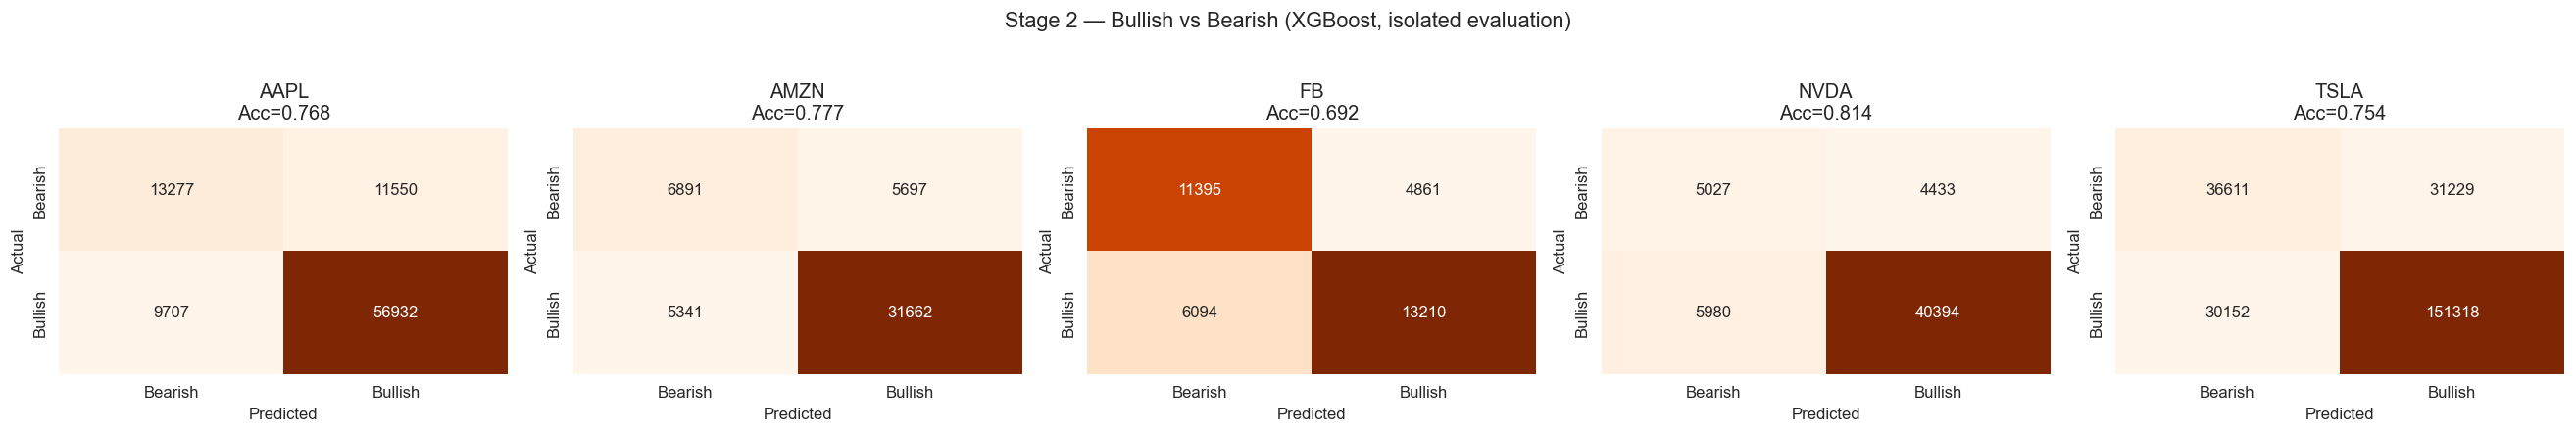

Saved → stage2_confusion_matrices.png


In [8]:
# ── Stage 2 Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
fig.suptitle("Stage 2 — Bullish vs Bearish (XGBoost, isolated evaluation)", fontsize=13, y=1.04)

for ax, stock in zip(axes, STOCKS):
    cm = stage2[stock]["cm"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Oranges",
        xticklabels=S2_NAMES, yticklabels=S2_NAMES,
        ax=ax, cbar=False,
    )
    acc = stage2[stock]["accuracy"]
    ax.set_title(f"{stock}\nAcc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("stage2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → stage2_confusion_matrices.png")

## 5 — Combined Pipeline: 3-Class Evaluation

The two models are **combined at inference time** to produce final 3-class predictions:

1. Stage 1 predicts "Neutral" → final label = **Neutral (0)**
2. Stage 1 predicts "Sentiment" → post goes to Stage 2 → final label = **Bearish (-1)** or **Bullish (1)**

This is the end-to-end evaluation against the true 3-class labels.


In [9]:
# ── Combined Pipeline: merge Stage 1 + Stage 2 → 3-class predictions ──
combined_results = {}

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]
    y_test_true = test_df["entities"].values  # true 3-class labels

    # Stage 1 predictions (0=Neutral, 1=Sentiment)
    y_s1 = stage1[stock]["y_pred"]

    # Indices where Stage 1 predicted "sentiment"
    sent_mask = y_s1 == 1
    n_sent = sent_mask.sum()
    n_neut = (~sent_mask).sum()

    # Build final 3-class prediction array
    y_combined = np.zeros(len(y_test_true), dtype=int)  # default to Neutral (0)

    if n_sent > 0:
        # Get text for posts Stage 1 flagged as sentiment
        test_text_sent = test_df.iloc[sent_mask]["body_no_stopwords"]

        # Transform with Stage 2's TF-IDF and predict
        X_sent_s2 = stage2[stock]["vec"].transform(test_text_sent)
        y_s2_xgb = stage2[stock]["clf"].predict(X_sent_s2)
        y_s2 = np.array([S2_LABEL_UNMAP[y] for y in y_s2_xgb])  # back to -1/1

        # Fill in sentiment predictions
        y_combined[sent_mask] = y_s2

    # ── 3-Class Metrics ──────────────────────────────────────────────
    acc = accuracy_score(y_test_true, y_combined)
    mcc = matthews_corrcoef(y_test_true, y_combined)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_true, y_combined, average="weighted", zero_division=0
    )
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_test_true, y_combined, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test_true, y_combined, labels=LABEL_ORDER)

    combined_results[stock] = {
        "accuracy": acc, "f1_weighted": f1_w, "f1_macro": f1_m,
        "precision_weighted": prec_w, "recall_weighted": rec_w,
        "precision_macro": prec_m, "recall_macro": rec_m,
        "mcc": mcc, "cm": cm,
        "y_test": y_test_true, "y_pred": y_combined,
        "n_sent_predicted": n_sent, "n_neut_predicted": n_neut,
    }

    # Print report
    print("=" * 60)
    print(f"  {stock} — Two-Stage Combined (3-Class)")
    print("=" * 60)
    print(f"  Accuracy : {acc:.4f}   MCC : {mcc:.4f}")
    print(f"  F1 (wtd) : {f1_w:.4f}   F1 (macro) : {f1_m:.4f}")
    print(f"  Stage 1 routed: {n_neut:,} → Neutral  |  {n_sent:,} → Stage 2")
    print()
    print(classification_report(
        y_test_true, y_combined, labels=LABEL_ORDER,
        target_names=LABEL_NAMES, zero_division=0
    ))

print("Combined evaluation complete.")

  AAPL — Two-Stage Combined (3-Class)
  Accuracy : 0.5539   MCC : 0.2730
  F1 (wtd) : 0.5507   F1 (macro) : 0.5103
  Stage 1 routed: 65,993 → Neutral  |  93,877 → Stage 2

              precision    recall  f1-score   support

     Bearish       0.39      0.33      0.36     24827
     Neutral       0.58      0.56      0.57     68404
     Bullish       0.58      0.63      0.61     66639

    accuracy                           0.55    159870
   macro avg       0.52      0.51      0.51    159870
weighted avg       0.55      0.55      0.55    159870

  AMZN — Two-Stage Combined (3-Class)
  Accuracy : 0.5561   MCC : 0.2723
  F1 (wtd) : 0.5534   F1 (macro) : 0.5097
  Stage 1 routed: 34,309 → Neutral  |  50,618 → Stage 2

              precision    recall  f1-score   support

     Bearish       0.38      0.33      0.35     12588
     Neutral       0.56      0.55      0.56     35336
     Bullish       0.60      0.64      0.62     37003

    accuracy                           0.56     84927
   

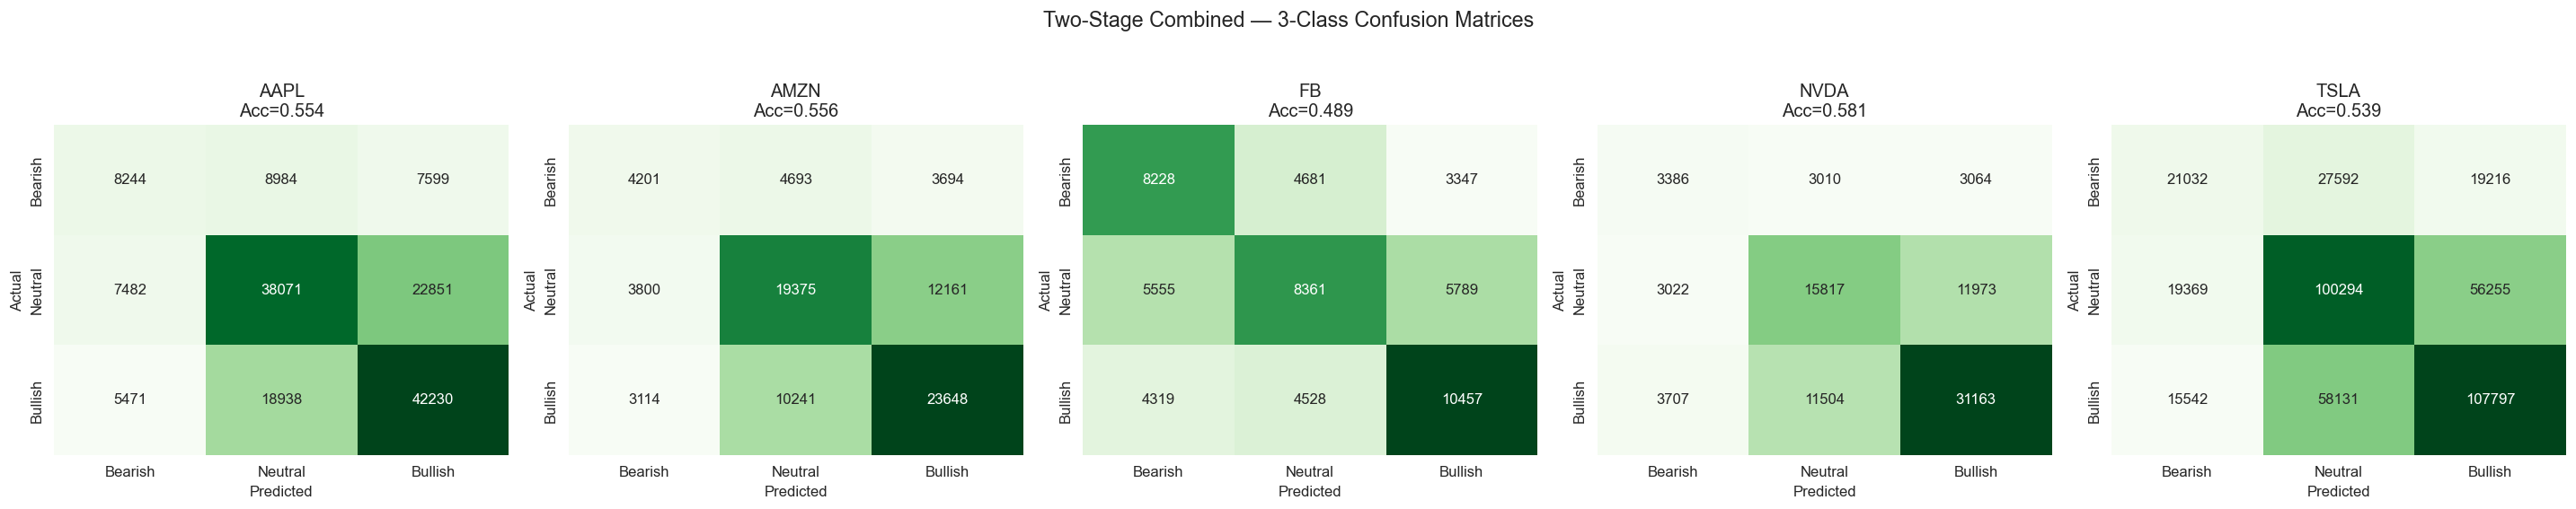

Saved → combined_confusion_matrices.png


In [10]:
# ── Combined 3-Class Confusion Matrices ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
fig.suptitle("Two-Stage Combined — 3-Class Confusion Matrices", fontsize=14, y=1.04)

for ax, stock in zip(axes, STOCKS):
    cm = combined_results[stock]["cm"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        ax=ax, cbar=False,
    )
    acc = combined_results[stock]["accuracy"]
    ax.set_title(f"{stock}\nAcc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("combined_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → combined_confusion_matrices.png")

## 6 — Error Analysis: Cascade Breakdown

In a two-stage pipeline, errors cascade: if Stage 1 misclassifies a Bullish post as Neutral, it never reaches Stage 2 — that's a guaranteed final error regardless of Stage 2's accuracy.

This analysis breaks down where errors originate:

- **Stage 1 kills**: true sentiment posts wrongly classified as Neutral (lost before Stage 2)
- **Stage 1 leaks**: true Neutral posts wrongly sent to Stage 2
- **Stage 2 flips**: posts correctly routed by Stage 1 but misclassified by Stage 2


In [11]:
# ── Error Analysis: where does the cascade fail? ─────────────────────
error_rows = []

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]
    y_true = test_df["entities"].values       # true 3-class labels
    y_s1   = stage1[stock]["y_pred"]           # Stage 1: 0=Neutral, 1=Sentiment
    y_comb = combined_results[stock]["y_pred"] # final combined prediction

    n_test = len(y_true)

    # True class masks
    true_bearish = y_true == -1
    true_neutral = y_true == 0
    true_bullish = y_true == 1
    true_sentiment = true_bearish | true_bullish

    # Stage 1 errors
    s1_kills = true_sentiment & (y_s1 == 0)   # sentiment → wrongly called Neutral
    s1_leaks = true_neutral & (y_s1 == 1)     # neutral → wrongly sent to Stage 2

    # Stage 2 errors (among posts correctly routed by Stage 1)
    correctly_routed = true_sentiment & (y_s1 == 1)
    s2_flips = correctly_routed & (y_comb != y_true)

    # Total errors
    total_errors = (y_comb != y_true).sum()

    row = {
        "Stock": stock,
        "Test Size": n_test,
        "Total Errors": total_errors,
        "Error Rate": round(total_errors / n_test, 4),
        "S1 Kills (sent→neut)": s1_kills.sum(),
        "S1 Leaks (neut→sent)": s1_leaks.sum(),
        "S2 Flips (wrong dir)": s2_flips.sum(),
        "S1 Kills %": round(s1_kills.sum() / max(total_errors, 1) * 100, 1),
        "S1 Leaks %": round(s1_leaks.sum() / max(total_errors, 1) * 100, 1),
        "S2 Flips %": round(s2_flips.sum() / max(total_errors, 1) * 100, 1),
    }
    error_rows.append(row)

    print(f"\n{'='*60}")
    print(f"  {stock} — Error Breakdown ({total_errors:,} total errors of {n_test:,} test posts)")
    print(f"{'='*60}")
    print(f"  Stage 1 kills (true sentiment → predicted Neutral):  {s1_kills.sum():>6,}  ({row['S1 Kills %']:5.1f}% of errors)")
    print(f"    - Bearish killed:  {(true_bearish & (y_s1==0)).sum():,}")
    print(f"    - Bullish killed:  {(true_bullish & (y_s1==0)).sum():,}")
    print(f"  Stage 1 leaks (true Neutral → sent to Stage 2):     {s1_leaks.sum():>6,}  ({row['S1 Leaks %']:5.1f}% of errors)")
    print(f"  Stage 2 flips (correct route, wrong direction):     {s2_flips.sum():>6,}  ({row['S2 Flips %']:5.1f}% of errors)")

    # Sentiment recall = % of true sentiment posts that made it to Stage 2
    sent_recall = 1 - s1_kills.sum() / max(true_sentiment.sum(), 1)
    print(f"\n  Sentiment recall (S1): {sent_recall:.4f} — bounds overall accuracy")

error_df = pd.DataFrame(error_rows).set_index("Stock")
print("\n" + "=" * 70)
print("  ERROR BREAKDOWN SUMMARY")
print("=" * 70)
display(error_df)


  AAPL — Error Breakdown (71,325 total errors of 159,870 test posts)
  Stage 1 kills (true sentiment → predicted Neutral):  27,922  ( 39.1% of errors)
    - Bearish killed:  8,984
    - Bullish killed:  18,938
  Stage 1 leaks (true Neutral → sent to Stage 2):     30,333  ( 42.5% of errors)
  Stage 2 flips (correct route, wrong direction):     13,070  ( 18.3% of errors)

  Sentiment recall (S1): 0.6947 — bounds overall accuracy

  AMZN — Error Breakdown (37,703 total errors of 84,927 test posts)
  Stage 1 kills (true sentiment → predicted Neutral):  14,934  ( 39.6% of errors)
    - Bearish killed:  4,693
    - Bullish killed:  10,241
  Stage 1 leaks (true Neutral → sent to Stage 2):     15,961  ( 42.3% of errors)
  Stage 2 flips (correct route, wrong direction):      6,808  ( 18.1% of errors)

  Sentiment recall (S1): 0.6989 — bounds overall accuracy

  FB — Error Breakdown (28,219 total errors of 55,265 test posts)
  Stage 1 kills (true sentiment → predicted Neutral):   9,209  ( 32.6%

,Test Size,Total Errors,Error Rate,S1 Kills (sent→neut),S1 Leaks (neut→sent),S2 Flips (wrong dir),S1 Kills %,S1 Leaks %,S2 Flips %
Stock,,,,,,,,,
AAPL,159870,71325,0.4461,27922,30333,13070,39.1,42.5,18.3
AMZN,84927,37703,0.4439,14934,15961,6808,39.6,42.3,18.1
FB,55265,28219,0.5106,9209,11344,7666,32.6,40.2,27.2
NVDA,86646,36280,0.4187,14514,14995,6771,40.0,41.3,18.7
TSLA,425228,196105,0.4612,85723,75624,34758,43.7,38.6,17.7


## 7 — Summary Table & Comparison Charts

Per-stock and cross-stock metrics for both stages and the combined pipeline.


In [12]:
# ── Summary Table ─────────────────────────────────────────────────────
summary_rows = []
for stock in STOCKS:
    s1 = stage1[stock]
    s2 = stage2[stock]
    cb = combined_results[stock]

    summary_rows.append({
        "Stock": stock,
        "S1 Acc (Sent/Neut)": round(s1["accuracy"], 4),
        "S1 F1 (wtd)": round(s1["f1_weighted"], 4),
        "S1 MCC": round(s1["mcc"], 4),
        "S2 Acc (Bull/Bear)": round(s2["accuracy"], 4),
        "S2 F1 (wtd)": round(s2["f1_weighted"], 4),
        "S2 MCC": round(s2["mcc"], 4),
        "Combined Acc": round(cb["accuracy"], 4),
        "Combined F1 (wtd)": round(cb["f1_weighted"], 4),
        "Combined F1 (macro)": round(cb["f1_macro"], 4),
        "Combined MCC": round(cb["mcc"], 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Stock")

print("=" * 80)
print("  TWO-STAGE CLASSIFIER — FULL SUMMARY")
print("=" * 80)
display(summary_df)

  TWO-STAGE CLASSIFIER — FULL SUMMARY


,S1 Acc (Sent/Neut),S1 F1 (wtd),S1 MCC,S2 Acc (Bull/Bear),S2 F1 (wtd),S2 MCC,Combined Acc,Combined F1 (wtd),Combined F1 (macro),Combined MCC
Stock,,,,,,,,,,
AAPL,0.6356,0.6347,0.2525,0.7676,0.7647,0.3989,0.5539,0.5507,0.5103,0.2730
AMZN,0.6362,0.6354,0.2483,0.7774,0.7764,0.4070,0.5561,0.5534,0.5097,0.2723
FB,0.6281,0.6229,0.1701,0.6919,0.6925,0.3839,0.4894,0.4886,0.4884,0.2343
NVDA,0.6594,0.6588,0.2543,0.8135,0.8190,0.3795,0.5813,0.5821,0.5122,0.2748
TSLA,0.6206,0.6219,0.2246,0.7538,0.7532,0.3754,0.5388,0.5357,0.4950,0.2493


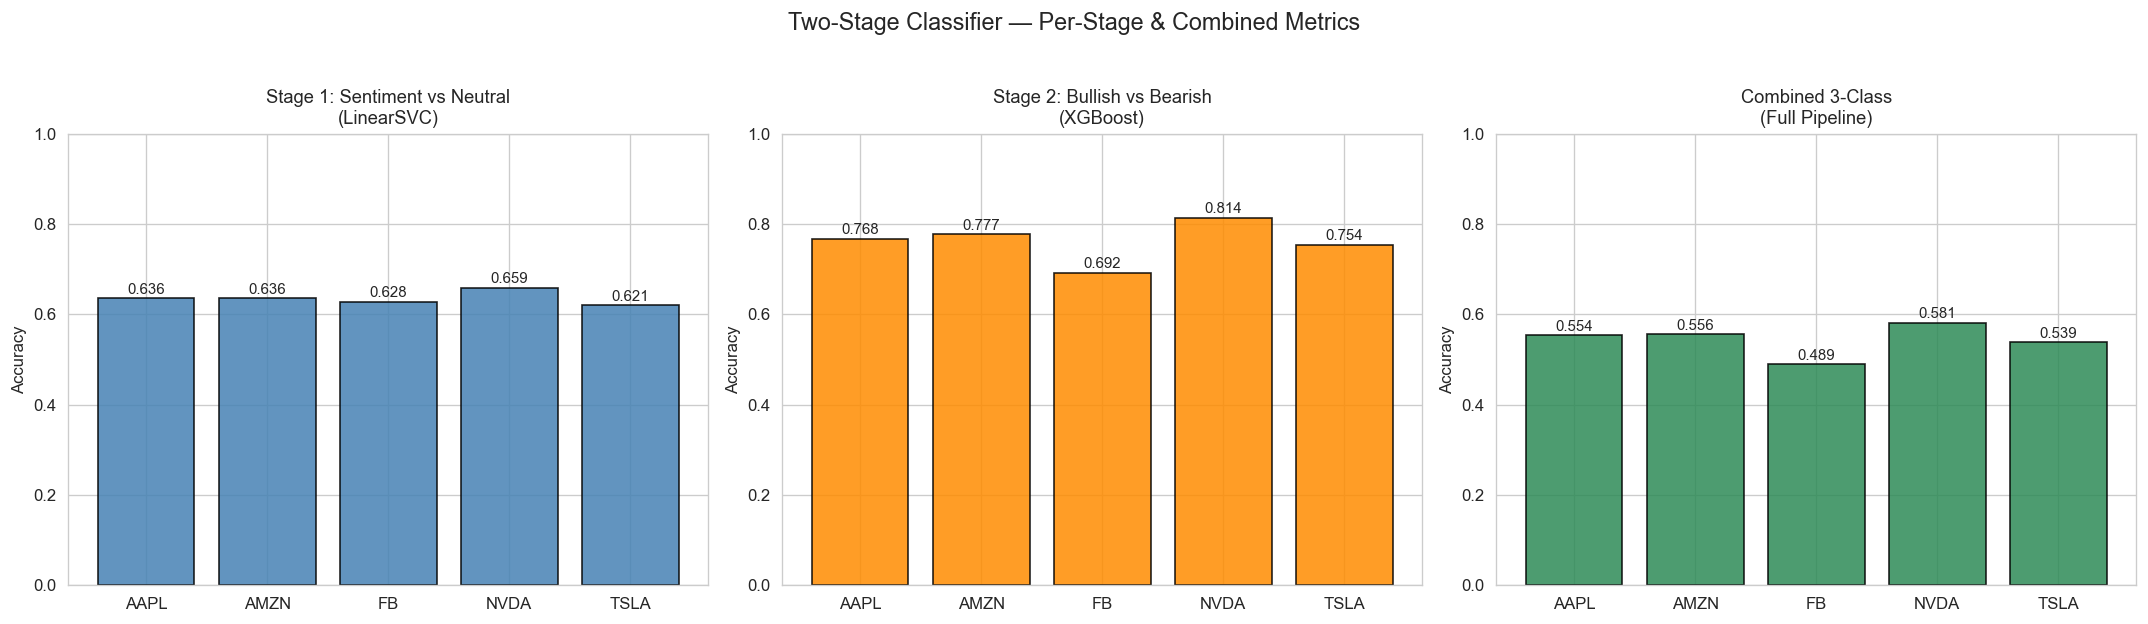

Saved → two_stage_accuracy_comparison.png


In [13]:
# ── Comparison Bar Charts ─────────────────────────────────────────────
# Chart 1: Per-stage accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Two-Stage Classifier — Per-Stage & Combined Metrics", fontsize=14, y=1.03)

# Stage 1 Accuracy
ax = axes[0]
s1_accs = [stage1[s]["accuracy"] for s in STOCKS]
bars = ax.bar(STOCKS, s1_accs, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_title("Stage 1: Sentiment vs Neutral\n(LinearSVC)", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
for i, v in enumerate(s1_accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# Stage 2 Accuracy
ax = axes[1]
s2_accs = [stage2[s]["accuracy"] for s in STOCKS]
bars = ax.bar(STOCKS, s2_accs, color="darkorange", edgecolor="black", alpha=0.85)
ax.set_title("Stage 2: Bullish vs Bearish\n(XGBoost)", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
for i, v in enumerate(s2_accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# Combined 3-class accuracy
ax = axes[2]
cb_accs = [combined_results[s]["accuracy"] for s in STOCKS]
bars = ax.bar(STOCKS, cb_accs, color="seagreen", edgecolor="black", alpha=0.85)
ax.set_title("Combined 3-Class\n(Full Pipeline)", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
for i, v in enumerate(cb_accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("two_stage_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → two_stage_accuracy_comparison.png")

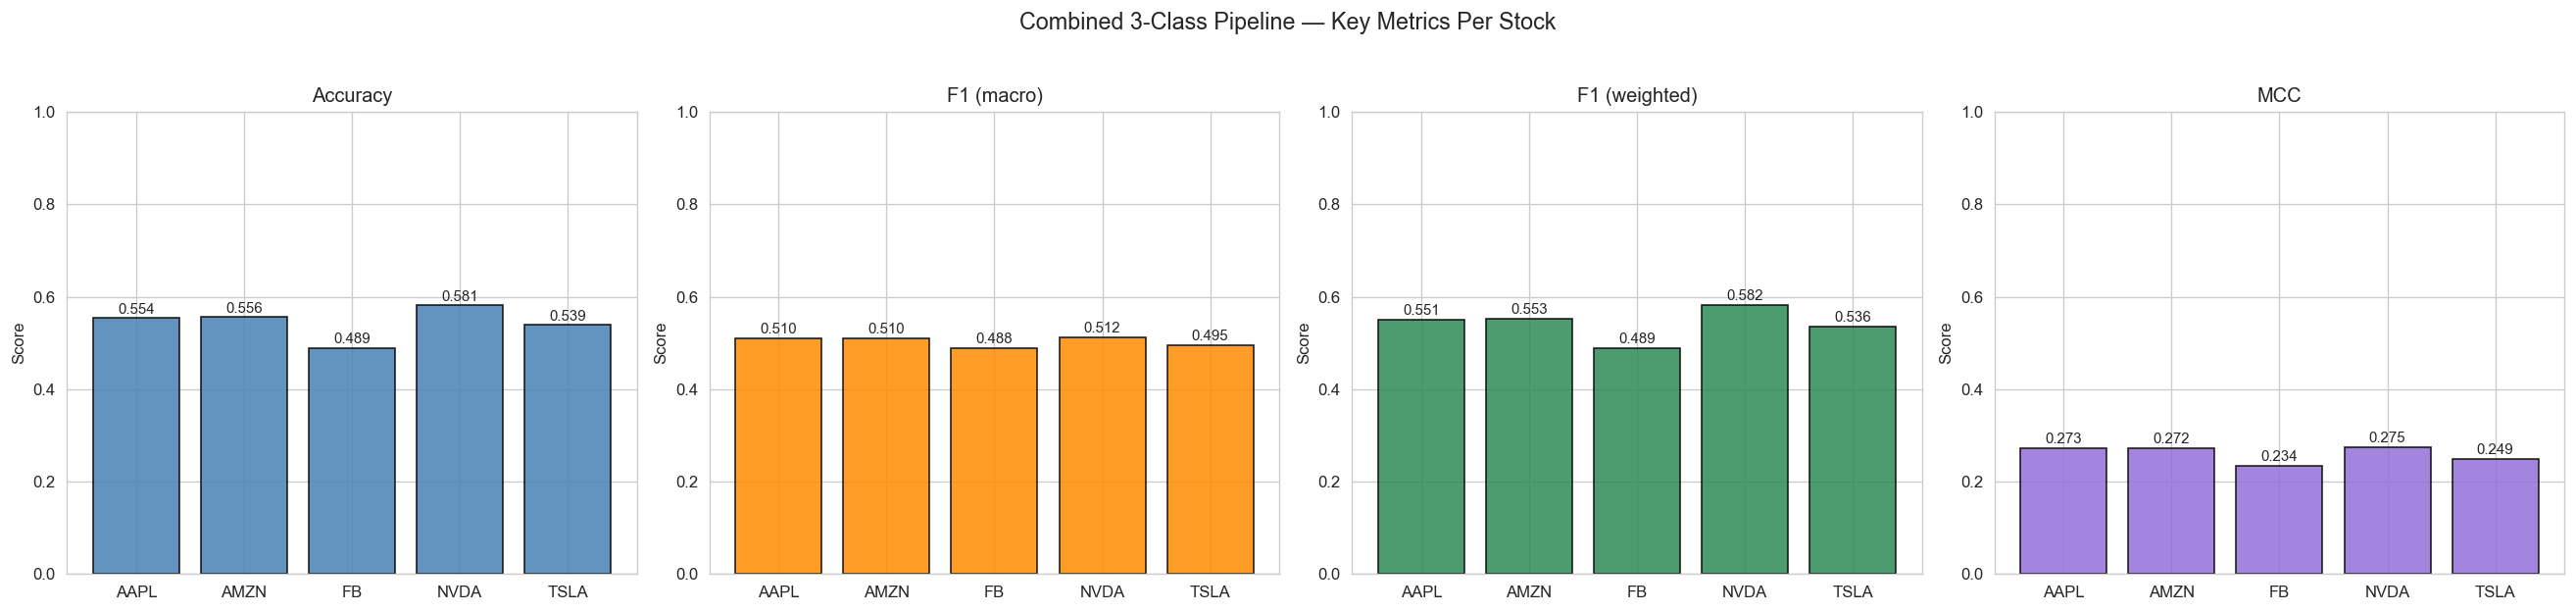

Saved → two_stage_combined_metrics.png


In [14]:
# ── Combined Metrics Bar Chart (Accuracy, F1 macro, F1 weighted, MCC) ──
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Combined 3-Class Pipeline — Key Metrics Per Stock", fontsize=14, y=1.03)

metrics_chart = [
    ("Accuracy", "accuracy", "steelblue"),
    ("F1 (macro)", "f1_macro", "darkorange"),
    ("F1 (weighted)", "f1_weighted", "seagreen"),
    ("MCC", "mcc", "mediumpurple"),
]

for ax, (label, key, color) in zip(axes, metrics_chart):
    vals = [combined_results[s][key] for s in STOCKS]
    ax.bar(STOCKS, vals, color=color, edgecolor="black", alpha=0.85)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, max(1.0, max(vals) * 1.15))
    ax.set_ylabel("Score")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("two_stage_combined_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → two_stage_combined_metrics.png")

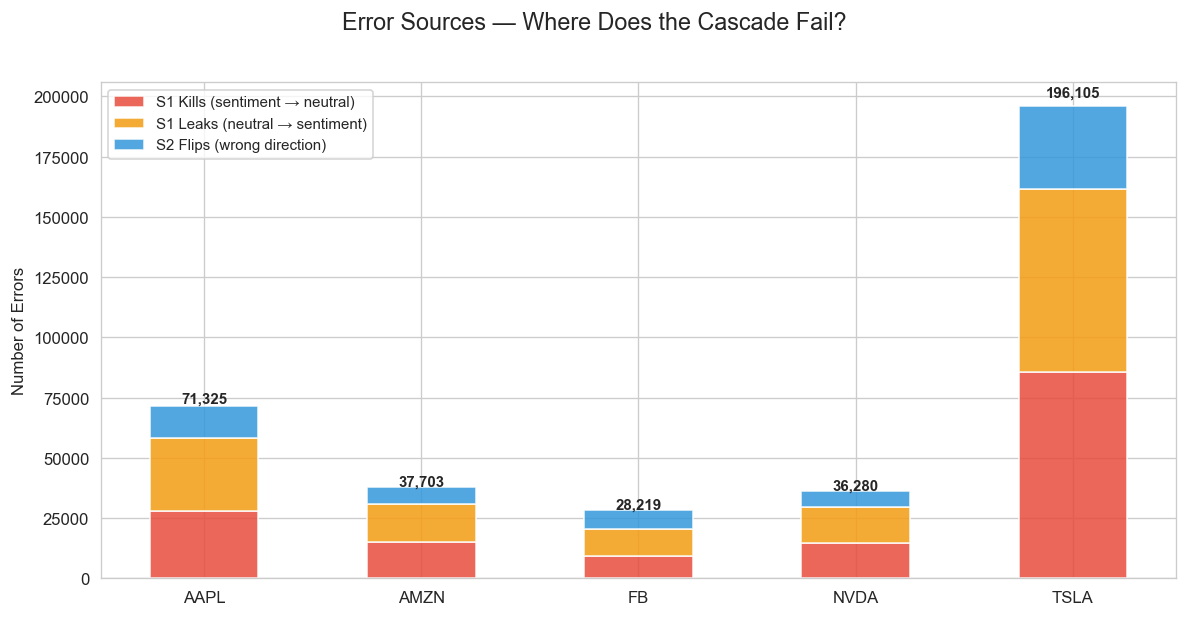

Saved → error_source_breakdown.png


In [15]:
# ── Error Source Stacked Bar Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Error Sources — Where Does the Cascade Fail?", fontsize=14, y=1.02)

x = np.arange(len(STOCKS))
width = 0.5

s1_kills = [error_df.loc[s, "S1 Kills (sent→neut)"] for s in STOCKS]
s1_leaks = [error_df.loc[s, "S1 Leaks (neut→sent)"] for s in STOCKS]
s2_flips = [error_df.loc[s, "S2 Flips (wrong dir)"] for s in STOCKS]

ax.bar(x, s1_kills, width, label="S1 Kills (sentiment → neutral)", color="#e74c3c", alpha=0.85)
ax.bar(x, s1_leaks, width, bottom=s1_kills, label="S1 Leaks (neutral → sentiment)", color="#f39c12", alpha=0.85)
ax.bar(x, s2_flips, width,
       bottom=[a + b for a, b in zip(s1_kills, s1_leaks)],
       label="S2 Flips (wrong direction)", color="#3498db", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(STOCKS)
ax.set_ylabel("Number of Errors")
ax.legend(loc="upper left", fontsize=9)

# Add total error count labels
for i in range(len(STOCKS)):
    total = s1_kills[i] + s1_leaks[i] + s2_flips[i]
    ax.text(i, total + total * 0.02, f"{total:,}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("error_source_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → error_source_breakdown.png")